In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img,img_to_array
import matplotlib.pyplot as plt

### Loading CSV file which contains image's names

In [2]:
#Loading just 1,000 examples because my cute little system(Core i5-3437U) with barely working fan might die if i trained using 200,000 examples
#The csv file consists of three columns where first is anchor(person), second image is positive(same person) and third is negative(different person)
df = pd.read_csv('training_triplet.csv',nrows=1000)
df.head()

,file1,file2,file3
0,007294.jpg,109830.jpg,148336.jpg
1,084495.jpg,065154.jpg,080852.jpg
2,008748.jpg,149864.jpg,065972.jpg
3,052764.jpg,151572.jpg,115456.jpg
4,198221.jpg,202437.jpg,089005.jpg


### Creating Triplet Generator with augmentation

In [3]:
#Adding augmentation for rescaling between (0,1), different brightness values, zoom range and horizontal flip
generator = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.7,1.5],
    zoom_range=0.2,
    horizontal_flip=True,
)
#Creating custom generator because we need to be able to pull 3 images at once
class TripletGenerator(tf.keras.utils.Sequence):
    def __init__(self,df,batch_size,image_size):
        self.df = df
        self.batch_size = batch_size
        self.image_size = image_size
    def __len__(self):
        return len(self.df)//self.batch_size
    def __getitem__(self,index):
        anchor,positive,negative = [],[],[]
        for i in range(self.batch_size):
            df_index = index*self.batch_size+i
            if df_index>= len(self.df):
                break
            anchor_path = 'Dataset/images/'+df.loc[df_index,'file1']
            positive_path = 'Dataset/images/'+df.loc[df_index,'file2']
            negative_path = 'Dataset/images/'+df.loc[df_index,'file3']
            an_img = img_to_array(load_img(anchor_path,target_size=self.image_size))/255
            pos_img = img_to_array(load_img(positive_path,target_size=self.image_size))/255
            neg_img = img_to_array(load_img(negative_path,target_size=self.image_size))/255
            anchor.append(an_img)
            positive.append(pos_img)
            negative.append(neg_img)
        #Adding all 3 of the into a single list so that it can be directly given to the model
        inputs = [np.array(anchor),np.array(positive),np.array(negative)]
        #Creating zero based labels because keras expects labels from generators
        labels = np.zeros((self.batch_size,))
        return inputs,labels
#Instantiating triplet_generator
triplet_generator = TripletGenerator(df,batch_size=32,image_size=(128,128,3))

### Creating Resnet architecture for base

In [4]:
#Base convolutional block which repeats with different parameters
def convolutional_block(x,filters,kernel_size,strides=2):
    f1,f2,f3 = filters
    residual = x
    x = tf.keras.layers.Conv2D(f1,(1,1),strides=strides,padding='valid')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(f2,kernel_size=kernel_size,strides=1,padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(f3,(1,1),strides=1,padding='valid')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    residual = tf.keras.layers.Conv2D(f3,(1,1),strides=strides,padding='valid')(residual)
    residual = tf.keras.layers.BatchNormalization()(residual)
    result = tf.keras.layers.Add()([x,residual])
    result = tf.keras.layers.Activation('relu')(result)
    return result
#Base identity block which repeats in a sequence
def identity_block(x,filters,kernel_size):
    f1,f2,f3 = filters
    residual = x
    x = tf.keras.layers.Conv2D(f1,(1,1),strides=1,padding='valid')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(f2,kernel_size=kernel_size,strides=1,padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(f3,(1,1),strides=1,padding='valid')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    result = tf.keras.layers.Add()([residual,x])
    result = tf.keras.layers.Activation('relu')(result)
    return result

input = tf.keras.Input(shape=(128,128,3))
x = tf.keras.layers.Conv2D(64,(7,7),strides=2,padding='same')(input)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)
x = convolutional_block(x,filters=[64,64,256],kernel_size=3,strides=1)
x = identity_block(x,filters=[64,64,256],kernel_size=3)
x = convolutional_block(x,filters=[128,128,512],kernel_size=3)
x = identity_block(x,filters=[128,128,512],kernel_size=3)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(1024,activation='relu')(x)
#Setting output dimension to be 512
output = tf.keras.layers.Dense(512,activation='linear')(x)
resnet_base = tf.keras.Model(input,output)

In [5]:
resnet_base.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 64, 64, 64)           9472      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 64, 64, 64)           256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 64, 64, 64)           0         ['batch_normalization[0][0

### Creating VGG(modified) architecture for base

In [6]:
#VGG16 model with sequence of 2,2,3,3,3
input = tf.keras.layers.Input(shape=(128,128,3))
x = tf.keras.layers.Conv2D(64,(3,3),strides=1,padding='same')(input)
x = tf.keras.layers.Conv2D(64,(3,3),strides=1,padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Conv2D(128,(3,3),strides=1,padding='same')(x)
x = tf.keras.layers.Conv2D(128,(3,3),strides=1,padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Conv2D(256,(3,3),strides=1,padding='same')(x)
x = tf.keras.layers.Conv2D(256,(3,3),strides=1,padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Dense(1024,activation='relu')(x)
#Again output dimension to be 512
output = tf.keras.layers.Dense(512,activation='linear')(x)
vgg_base = tf.keras.Model(inputs=input,outputs=output)

In [7]:
vgg_base.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv2d_15 (Conv2D)          (None, 128, 128, 64)      1792      
                                                                 
 conv2d_16 (Conv2D)          (None, 128, 128, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 64, 64, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_17 (Conv2D)          (None, 64, 64, 128)       73856     
                                                                 
 conv2d_18 (Conv2D)          (None, 64, 64, 128)       147584    
                                                           

### Creating MobileNetV2 architecture as base

In [8]:
#Base bottleneck blocks which repeats 17 time throughout the model
def bottleneck_block(x,n_ch,p_ch,exp_factor,stride):
    e_ch = n_ch*exp_factor
    prev_x = x
    x = tf.keras.layers.Conv2D(e_ch,(1,1),strides=1,padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.DepthwiseConv2D((3,3),strides=stride,padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(p_ch,(1,1),strides=1,padding='same')(x)
    if e_ch==p_ch:
        x = tf.keras.layers.Add()([x,prev_x])
    return x
input = tf.keras.layers.Input(shape=(128,128,3))
x = tf.keras.layers.Conv2D(32,(3,3),strides=2,padding='same')(input)
x = bottleneck_block(x,32,16,1,1)
x = bottleneck_block(x,16,24,6,2)
x = bottleneck_block(x,24,24,6,2)
x = bottleneck_block(x,24,32,6,2)
x = bottleneck_block(x,32,32,6,2)
x = bottleneck_block(x,32,32,6,2)
x = bottleneck_block(x,32,64,6,2)
x = bottleneck_block(x,64,64,6,2)
x = bottleneck_block(x,64,64,6,2)
x = bottleneck_block(x,64,64,6,2)
x = bottleneck_block(x,64,96,6,1)
x = bottleneck_block(x,96,96,6,1)
x = bottleneck_block(x,96,96,6,1)
x = bottleneck_block(x,96,160,6,2)
x = bottleneck_block(x,160,160,6,2)
x = bottleneck_block(x,160,160,6,2)
x = bottleneck_block(x,160,320,6,1)

x = tf.keras.layers.Conv2D(1280,(1,1),padding='same',strides=1)(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
#Again 512 output dimension
output = tf.keras.layers.Dense(512,activation='linear')(x)
base_mobile_net = tf.keras.Model(inputs=input,outputs=output)

In [9]:
base_mobile_net.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv2d_21 (Conv2D)          (None, 64, 64, 32)        896       
                                                                 
 conv2d_22 (Conv2D)          (None, 64, 64, 32)        1056      
                                                                 
 batch_normalization_15 (Ba  (None, 64, 64, 32)        128       
 tchNormalization)                                               
                                                                 
 activation_13 (Activation)  (None, 64, 64, 32)        0         
                                                                 
 depthwise_conv2d (Depthwis  (None, 64, 64, 32)        320       
 eConv2D)                                                  

### Creating custom model class for processing three images at a time (in one forward and backward pass)

In [10]:
#Custom Model class to do the forward pass on all of 3 images on first then caluclate loss using triplet-loss and then backpropagate based on that loss
class Face_Recognition(tf.keras.Model):
    def __init__(self,recognition_model,margin=0.5):
        super().__init__()
        self.model = recognition_model
        self.margin = margin
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')
    #Defining call method to take three images at once and pass each image through the base model
    def call(self,inputs):
        print(inputs[0].shape)
        anchor = self.model(inputs[0])
        positive = self.model(inputs[1])
        negative = self.model(inputs[2])
        ap_distance = tf.reduce_sum(tf.square(anchor - positive),-1)
        an_distance = tf.reduce_sum(tf.square(anchor - negative),-1)
        return tf.stack([ap_distance, an_distance], axis=-1)
    #Defining one training step in which it should do a forward pass, remember steps of calculations using GradientTape, calculate and apply gradients
    def train_step(self,data):
        inputs, _ = data
        with tf.GradientTape() as tape:
            loss = self._compute_loss(inputs)
        gradient =  tape.gradient(loss,self.model.trainable_weights)
        self.optimizer.apply_gradients(
        zip(gradient,self.model.trainable_weights)
        )
        self.loss_tracker.update_state(loss)
        return {'loss':self.loss_tracker.result()}
    #Defining one test step same as training step except gradient calculation
    def test_step(self,data):
        inputs, _ = data
        loss = self._compute_loss(inputs)
        self.loss_tracker.update_state(loss)
        return {'loss':self.loss_tracker.result()}
    #Defining compute loss function which does the forward pass and calculates the loss along with margin
    def _compute_loss(self,data):
        anchor = self.model(data[0])
        positive = self.model(data[1])
        negative = self.model(data[2])
        ap_distance = tf.reduce_sum(tf.square(anchor - positive),-1)
        an_distance = tf.reduce_sum(tf.square(anchor - negative),-1)
        loss = ap_distance-an_distance
        #Selecting loss between either loss+margin or 0
        loss = tf.maximum(loss+self.margin,0)
        return loss
    #Providing a new implementation for metrics of the model to return the mean loss
    @property
    def metrics(self):
        return [self.loss_tracker]

### Training the custom model with Resnet50(output modified to be 512) as base

In [11]:
#Wrapping custom model around base ResNet model
resnet = Face_Recognition(resnet_base)
#Compiling using Adam
resnet.compile(optimizer=tf.keras.optimizers.Adam(0.001))

In [12]:
history = resnet.fit(x=triplet_generator,epochs=10)

(32, 128, 128, 3)
Epoch 1/10
31/31 [==============================] - 220s 7s/step - loss: 0.4762
Epoch 2/10
31/31 [==============================] - 211s 7s/step - loss: 0.4687
Epoch 3/10
31/31 [==============================] - 212s 7s/step - loss: 0.4617
Epoch 4/10
31/31 [==============================] - 212s 7s/step - loss: 0.4933
Epoch 5/10
31/31 [==============================] - 212s 7s/step - loss: 0.4722
Epoch 6/10
31/31 [==============================] - 212s 7s/step - loss: 0.4676
Epoch 7/10
31/31 [==============================] - 212s 7s/step - loss: 0.4635
Epoch 8/10
31/31 [==============================] - 211s 7s/step - loss: 0.4617
Epoch 9/10
31/31 [==============================] - 211s 7s/step - loss: 0.4587
Epoch 10/10
31/31 [==============================] - 215s 7s/step - loss: 0.4525


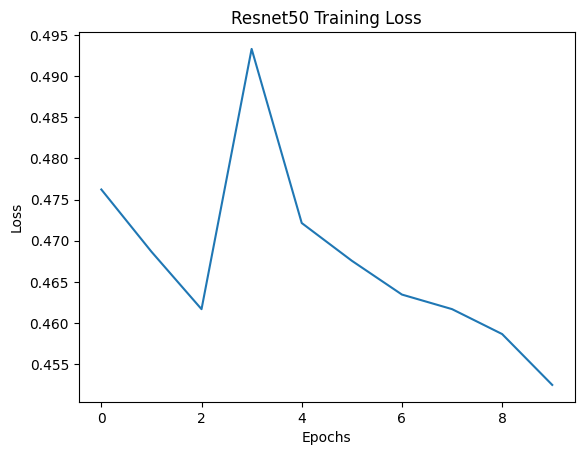

In [13]:
#Showing loss over time
plt.plot(history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Resnet50 Training Loss')
plt.show()

### Training custom model with VGG16(output modified to be 512) as base

In [14]:
#Wrapping custom model around base VGG model
vgg = Face_Recognition(vgg_base)
#Compiling using Adam
vgg.compile(optimizer=tf.keras.optimizers.Adam(0.001))

In [15]:
history = vgg.fit(x=triplet_generator,epochs=10)

(32, 128, 128, 3)
Epoch 1/10
31/31 [==============================] - 1274s 41s/step - loss: 0.5290
Epoch 2/10
31/31 [==============================] - 1270s 41s/step - loss: 0.4718
Epoch 3/10
16/31 [==============>...............] - ETA: 10:13 - loss: 0.4684

KeyboardInterrupt: 

In [ ]:
#Showing loss over time
plt.plot(history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('VGG16 Training Loss')
plt.show()

### Training custom model with MobileNetV2(output modified to be 512) as base

In [ ]:
#Wrapping custom model around base MobileNet
mobile_net = Face_Recognition(mobile_net_base)
#Compiling using Adam
mobile_net.compile(optimizer=tf.keras.optimizers.Adam(0.001))

In [ ]:
history = mobile_net.fit(x=triplet_generator,epochs=10)

In [ ]:
#Showing loss over time
plt.plot(history.history['loss'])
plt.xlabel('Epcohs')
plt.ylabel('Loss')
plt.title('MobileNetV2 Training Loss')
plt.show()